<a href="https://colab.research.google.com/github/GEO-HACK/watchtower-ml/blob/main/notebooks/combined_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression


#Loading all the data


In [3]:
DATASET = '/content/drive/MyDrive/CICICDS/'

# loading and concatenating all the datasets
all_files = [f for f in os.listdir(DATASET) if f.endswith('.csv')]
print(f"Found {len(all_files)} files: {all_files}")

dfs = []
for file in all_files:
  path = os.path.join(DATASET, file)
  df_temp = pd.read_csv(path, low_memory=False)
  df_temp['source_file'] = file #track which file each row came from
  dfs.append(df_temp)

print(f" {file} -shape: {df_temp.shape}")

df = pd.concat(dfs, ignore_index=True)
print(f"\ combined dataset shape: {df.shape}")

Found 6 files: ['Wednesday-workingHours.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv']
 Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -shape: (286467, 80)
\ combined dataset shape: (2371775, 80)


#initial exploration

In [5]:
print("=" * 60)
print("SHAPE:", df.shape)
print("=" * 60)

print("\n--- COLUMN NAMES ---")
print(df.columns.tolist())

print("\n--- DATA TYPES ---")
print(df.dtypes.value_counts())

print("\n--- FIRST 5 ROWS ---")
df.head()


SHAPE: (2371775, 80)

--- COLUMN NAMES ---
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH 

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Wednesday-workingHours.pcap_ISCX.csv


#labels column


--- CLASS DISTRIBUTION---
Label
BENIGN              1816345
DoS Hulk             231073
PortScan             158930
DDoS                 128027
DoS GoldenEye         10293
FTP-Patator            7938
SSH-Patator            5897
DoS slowloris          5796
DoS Slowhttptest       5499
Bot                    1966
Heartbleed               11
Name: count, dtype: int64

Total classes : 11


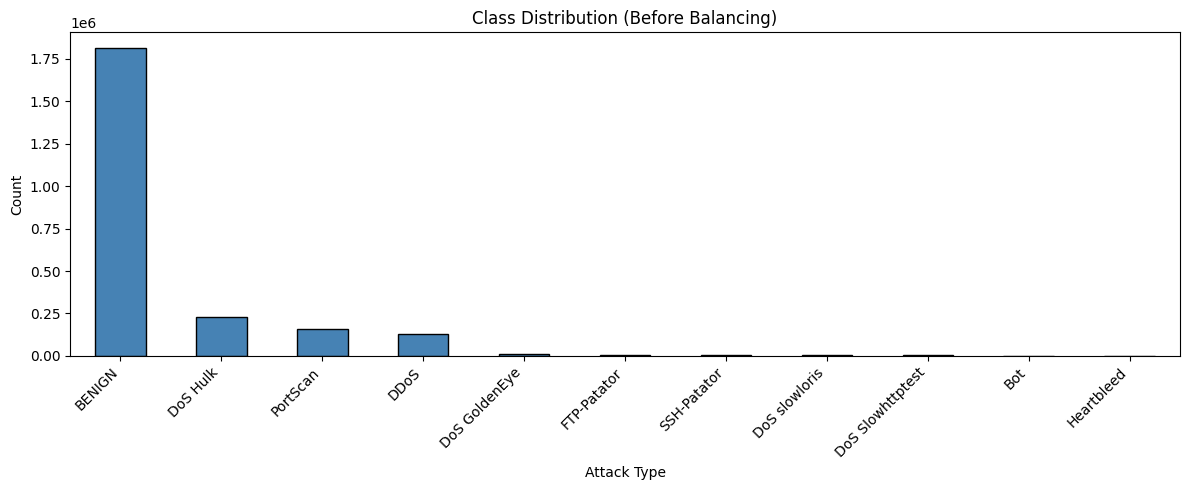

In [7]:
df.columns = df.columns.str.strip()

LABEL_COL = 'Label'

print("--- CLASS DISTRIBUTION---")
label_counts = df[LABEL_COL].value_counts()
print(label_counts)
print(f"\nTotal classes : {df[LABEL_COL].nunique()}")


# Plot
plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution (Before Balancing)')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#clean the data

In [9]:
print(f"Shape before cleaning: {df.shape}")

# strip the white spaces from the srings
df[LABEL_COL] = df[LABEL_COL].str.strip()

# replace infinity with nan
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop columns with more than 50% missing
before = df.shape[1]
df = df[df.columns[df.isnull().mean() < 0.5]]
print(f"Dropped {before - df.shape[1]} high-missing columns")

# 4. Drop constant columns (zero variance)
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)
print(f"Dropped {len(constant_cols)} constant columns: {constant_cols}")

# 5. Drop duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped {before - len(df)} duplicate rows")

# 6. Drop the source_file tracking column before modeling
df.drop(columns=['source_file'], inplace=True, errors='ignore')

print(f"\nShape after cleaning: {df.shape}")

Shape before cleaning: (2371775, 80)
Dropped 0 high-missing columns
Dropped 10 constant columns: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Dropped 214783 duplicate rows

Shape after cleaning: (2156992, 69)


#Missing values audit

                missing_count  missing_pct
Flow Bytes/s             1321     0.061243
Flow Packets/s           1321     0.061243


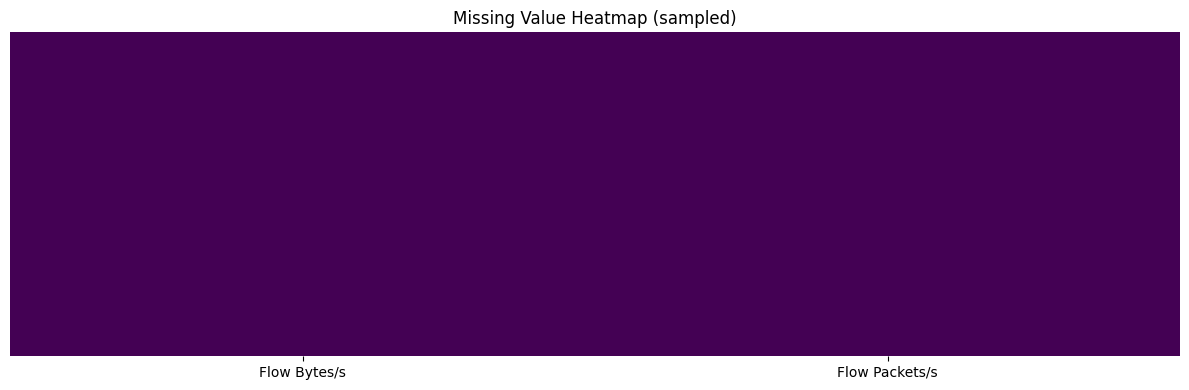

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'missing_count' : missing,
    'missing_pct' : missing_pct
}).query('missing_count > 0')
missing_df.sort_values('missing_pct', ascending=False)

print(missing_df)

#Heatmap of missing values
if not missing_df.empty:
    plt.figure(figsize=(12, 4))
    sns.heatmap(df[missing_df.index].isnull().sample(min(5000, len(df))),
                cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Missing Value Heatmap (sampled)')
    plt.tight_layout()
    plt.show()


#separate features and labels then split

In [ ]:
# Separate features and target
X = df.drop(columns=[LABEL_COL])
y = df[LABEL_COL]

#keep onlynumeric features

X = X.select_dtypes(include=[np.number])
print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution:\n{y.value_counts()}")

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"\nEncoded label distribution:\n{pd.Series(y_encoded).value_counts()}")

for cls, idx in zip(le.classes_, le.transform(le.classes_)):
  print(f"{idx} : {cls}")

  # saved the encoder to joblib

# joblib.dump(le, 'content/drive/MyDrive/CICICDS/label_encoder.pkl')

# Train/test split — BEFORE any imputation or scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # preserve class balance in split
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")


Feature matrix shape: (2156992, 68)
Label distribution:
Label
BENIGN              1733293
DoS Hulk             172849
DDoS                 128016
PortScan              90819
DoS GoldenEye         10286
FTP-Patator            5933
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Bot                    1953
Heartbleed               11
Name: count, dtype: int64

Encoded label distribution:
0     1733293
4      172849
2      128016
9       90819
3       10286
7        5933
6        5385
5        5228
10       3219
1        1953
8          11
Name: count, dtype: int64
0 : BENIGN
1 : Bot
2 : DDoS
3 : DoS GoldenEye
4 : DoS Hulk
5 : DoS Slowhttptest
6 : DoS slowloris
7 : FTP-Patator
8 : Heartbleed
9 : PortScan
10 : SSH-Patator


FileNotFoundError: [Errno 2] No such file or directory: 'content/drive/MyDrive/CICIDS/label_encoder.pkl'